<a href="https://colab.research.google.com/github/karanbeer23/Credit-Card-Detection-Fraud/blob/main/Credit_Card_Fraud_Detection_using_TPOT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
# https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data
data=pd.read_csv('/content/creditcard.csv')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11959 entries, 0 to 11958
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    11959 non-null  int64  
 1   V1      11959 non-null  float64
 2   V2      11959 non-null  float64
 3   V3      11959 non-null  float64
 4   V4      11959 non-null  float64
 5   V5      11959 non-null  float64
 6   V6      11959 non-null  float64
 7   V7      11959 non-null  float64
 8   V8      11959 non-null  float64
 9   V9      11959 non-null  float64
 10  V10     11959 non-null  float64
 11  V11     11959 non-null  float64
 12  V12     11959 non-null  float64
 13  V13     11959 non-null  float64
 14  V14     11959 non-null  float64
 15  V15     11959 non-null  float64
 16  V16     11959 non-null  float64
 17  V17     11959 non-null  float64
 18  V18     11959 non-null  float64
 19  V19     11959 non-null  float64
 20  V20     11958 non-null  float64
 21  V21     11958 non-null  float64
 22

In [5]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,11959.000000,...,11958.000000,11958.000000,11958.000000,11958.000000,11958.000000,11958.000000,11958.000000,11958.000000,11958.000000,11958.000000
mean,8009.996822,-0.216230,0.277097,0.889505,0.282606,-0.086585,0.139986,-0.121943,-0.048727,0.911579,...,-0.061474,-0.153850,-0.033709,0.017113,0.104794,0.062891,0.008320,0.000271,62.352617,0.004349
std,6204.332248,1.583914,1.308884,1.331824,1.478162,1.191776,1.306285,1.153899,1.246823,1.192349,...,0.918705,0.626631,0.505355,0.591394,0.429413,0.561603,0.405100,0.261230,178.247010,0.065803
min,0.000000,-27.670569,-34.607649,-22.804686,-4.657545,-32.092129,-23.496714,-26.548144,-23.632502,-7.175097,...,-11.468435,-8.593642,-19.254328,-2.512377,-4.781606,-1.338556,-7.976100,-3.575312,0.000000,0.000000
25%,2542.000000,-0.978944,-0.261503,0.417186,-0.622456,-0.688114,-0.622521,-0.591335,-0.185243,0.196741,...,-0.268151,-0.543613,-0.171833,-0.333251,-0.144092,-0.353864,-0.080064,-0.015461,5.000000,0.000000
50%,6662.000000,-0.340742,0.256346,0.951223,0.213029,-0.183847,-0.146903,-0.094876,0.013616,0.894911,...,-0.130062,-0.124900,-0.044299,0.072099,0.143136,0.001972,-0.003039,0.015452,15.950000,0.000000
75%,12382.000000,1.161273,0.883626,1.613678,1.159141,0.346298,0.508432,0.431657,0.267560,1.589120,...,0.021687,0.234029,0.075686,0.401798,0.380076,0.409231,0.106344,0.073171,50.000000,0.000000
max,20642.000000,1.960497,9.092123,4.101716,11.927512,34.099309,21.393069,34.303177,5.499963,10.392889,...,22.614889,4.534454,13.876221,3.200201,5.525093,3.517346,8.254376,4.860769,7712.430000,1.000000


Text(0, 0.5, 'Frequency')

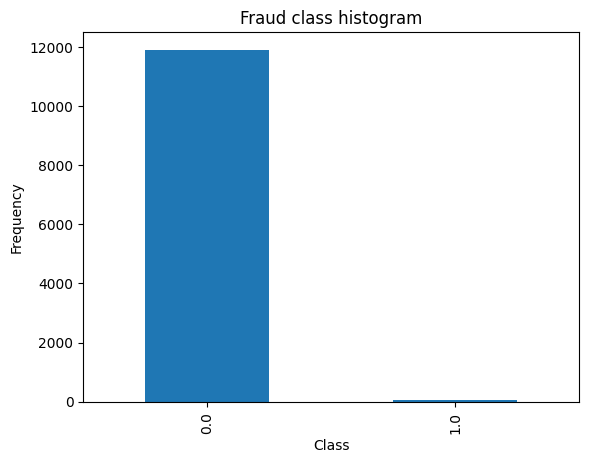

In [6]:
count_classes = data['Class'].value_counts(sort = True).sort_index()
count_classes.plot(kind = 'bar')
plt.title("Fraud class histogram")
plt.xlabel("Class")
plt.ylabel("Frequency")

Class 1 is Fraud

Class 0 is Not Fraud

In [7]:
data.Time[data.Class == 1].describe()

,Time
count,52.000000
mean,11569.615385
std,4973.192986
min,406.000000
25%,8040.250000
50%,11086.000000
75%,16159.500000
max,20451.000000


In [8]:
data.Time[data.Class == 0].describe()

,Time
count,11906.000000
mean,7993.389048
std,6204.041605
min,0.000000
25%,2524.500000
50%,6603.000000
75%,12353.750000
max,20638.000000


<Axes: >

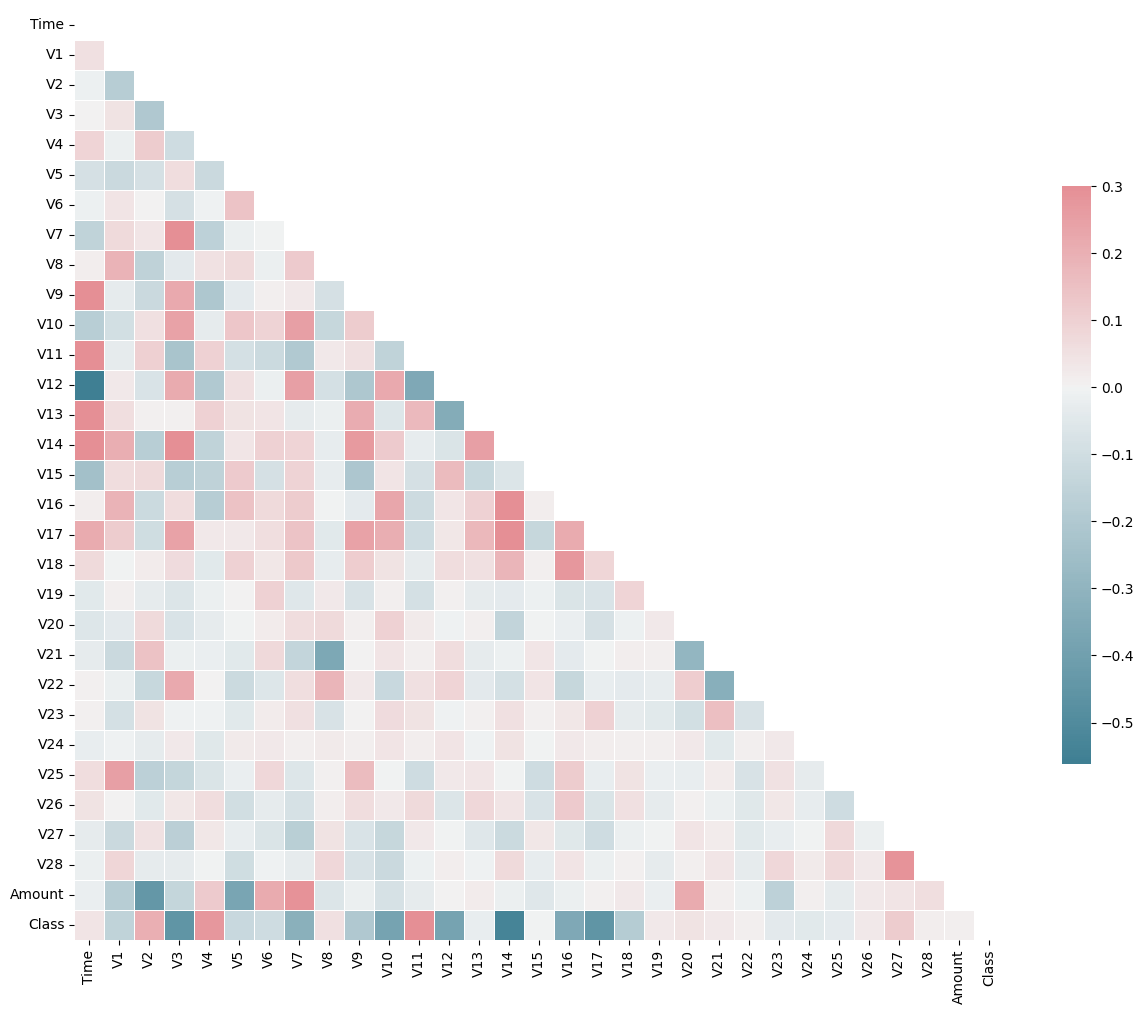

In [9]:
f, ax = plt.subplots(figsize=(15, 15))
corr = data.corr()
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr,mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

Features Vx don't seem to be related to each other.
Is this PCA?

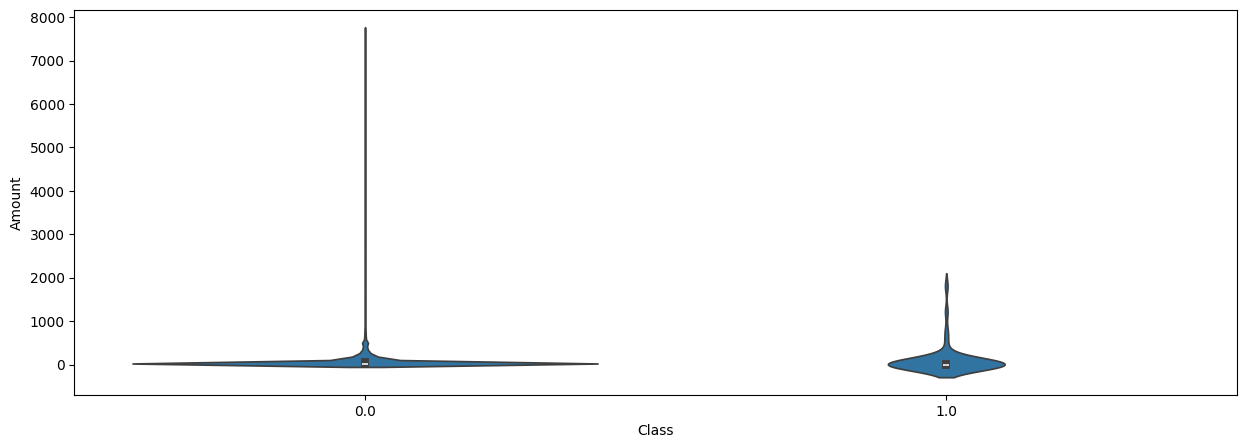

In [10]:
f, ax = plt.subplots(figsize=(15, 5))
ax = sns.violinplot(x="Class", y="Amount", data=data, density_norm='area')

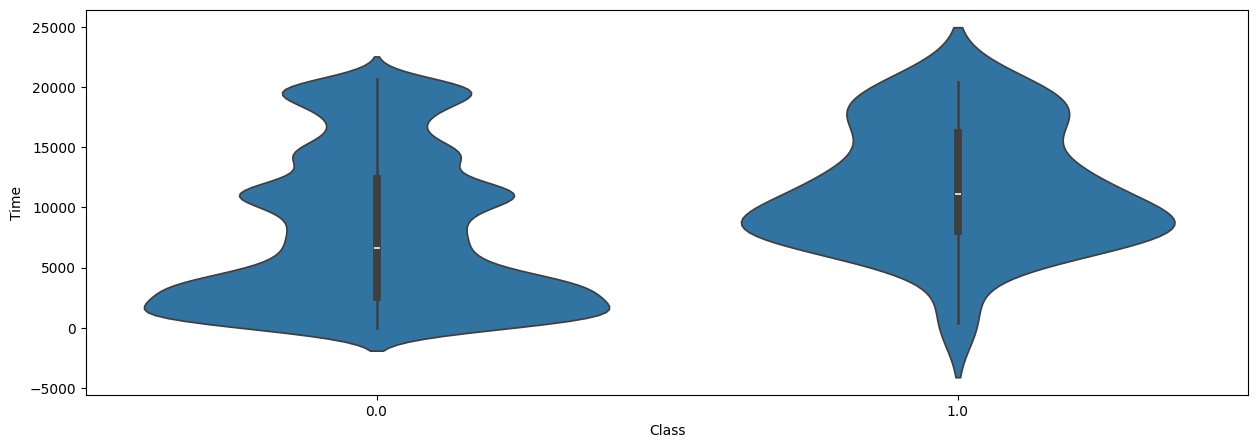

In [11]:
f, ax = plt.subplots(figsize=(15, 5))
ax = sns.violinplot(x="Class", y="Time", data=data, density_norm='area')

# Hypothesis 1,2

### Most of the transaction are less than 1000; Majority of the Fraud is taking place with less than 200.

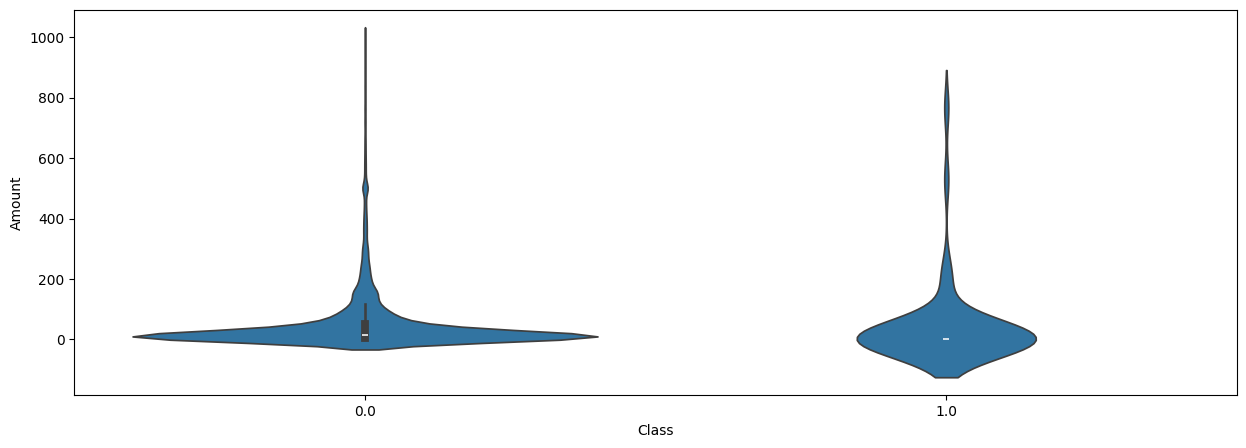

In [12]:
df1 = data[data.Amount <= 1000]
f, ax = plt.subplots(figsize=(15, 5))
ax = sns.violinplot(x="Class", y="Amount", data=df1, density_norm='area')

Let's revisit the correlation matrix for df1 (instead of data)

<Axes: >

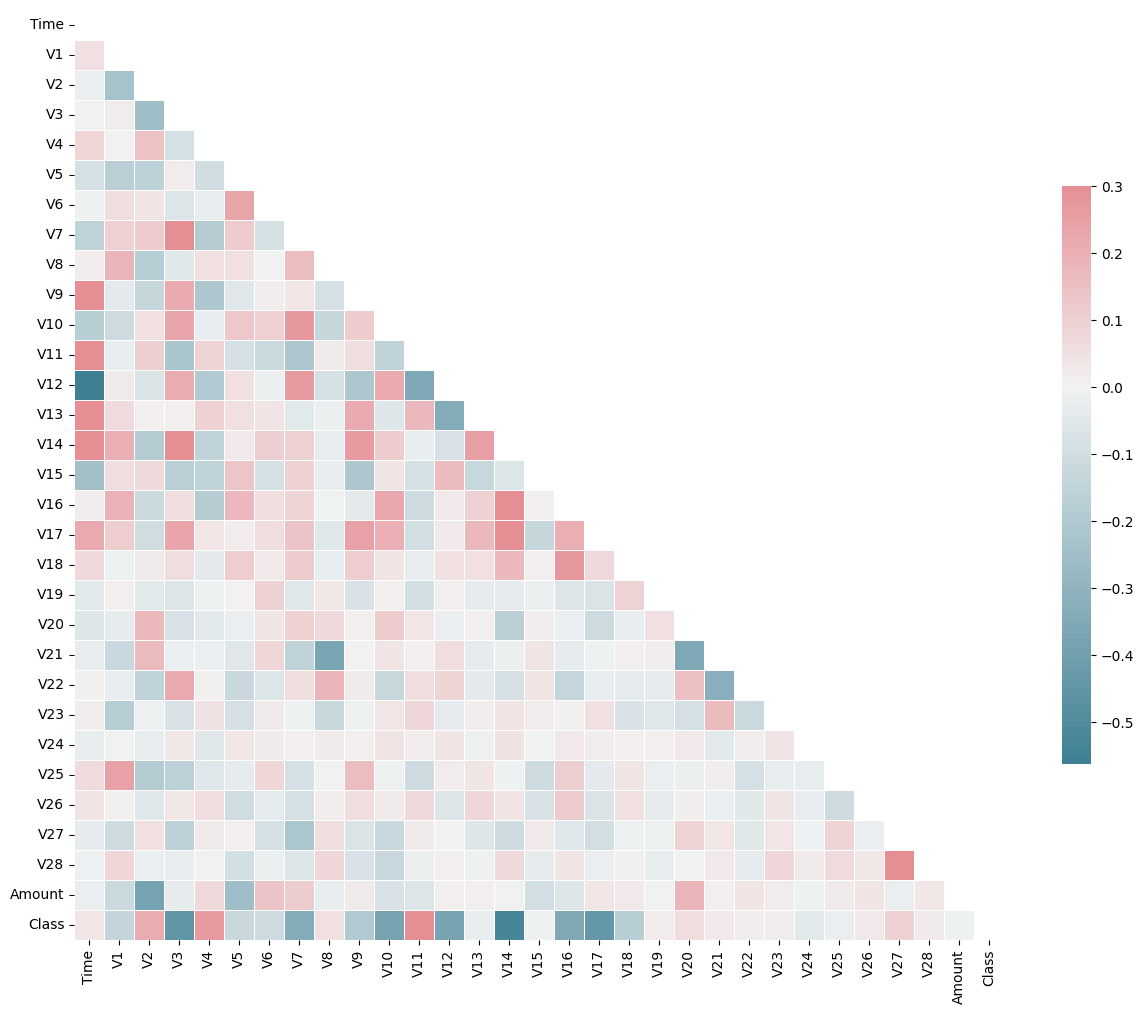

In [13]:
f, ax = plt.subplots(figsize=(15, 15))
corr = df1.corr()
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr,mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [14]:
print ("Fraud")
print (df1.Time[df1.Class == 1].describe())
print ("-"*50)
print ("-"*50)
print ("-"*50)
print ("Normal")
print (df1.Time[df1.Class == 0].describe())

Fraud
count       50.000000
mean     11489.360000
std       4973.964008
min        406.000000
25%       7940.750000
50%      11086.000000
75%      15400.750000
max      20451.000000
Name: Time, dtype: float64
--------------------------------------------------
--------------------------------------------------
--------------------------------------------------
Normal
count    11848.000000
mean      7998.210753
std       6205.522453
min          0.000000
25%       2531.250000
50%       6607.500000
75%      12362.750000
max      20638.000000
Name: Time, dtype: float64


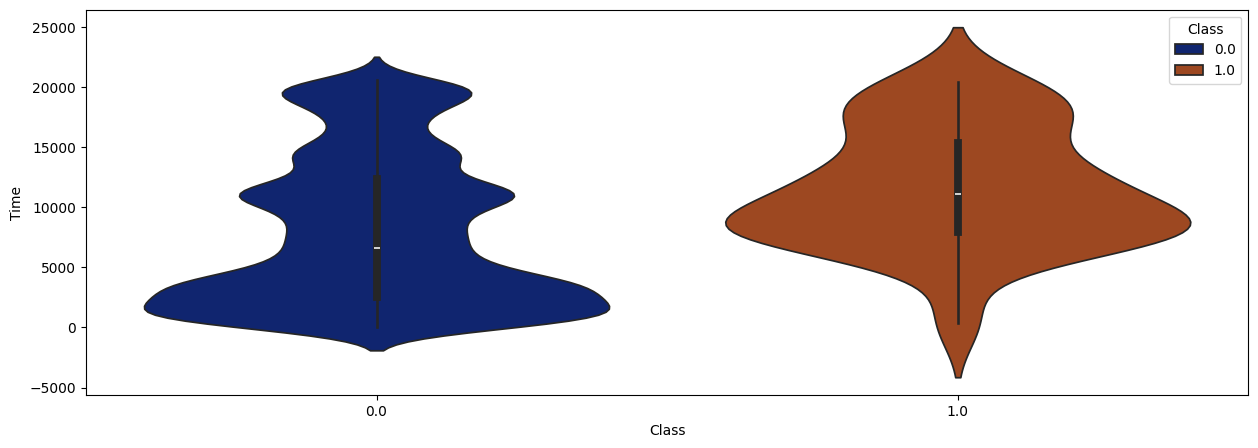

In [15]:
f, ax = plt.subplots(figsize=(15, 5))
ax = sns.violinplot(x="Class", y="Time", data=df1, density_norm='area',palette="dark", hue="Class")

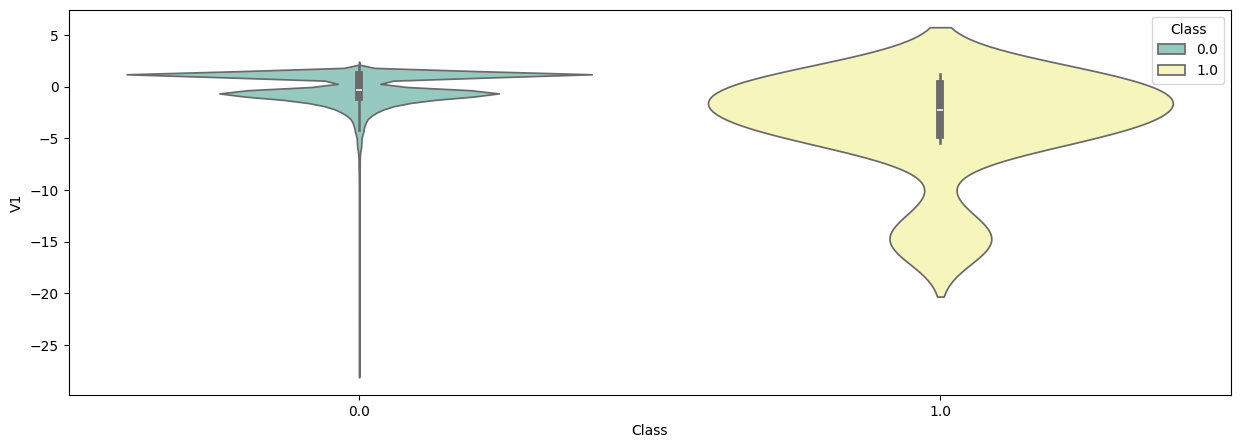

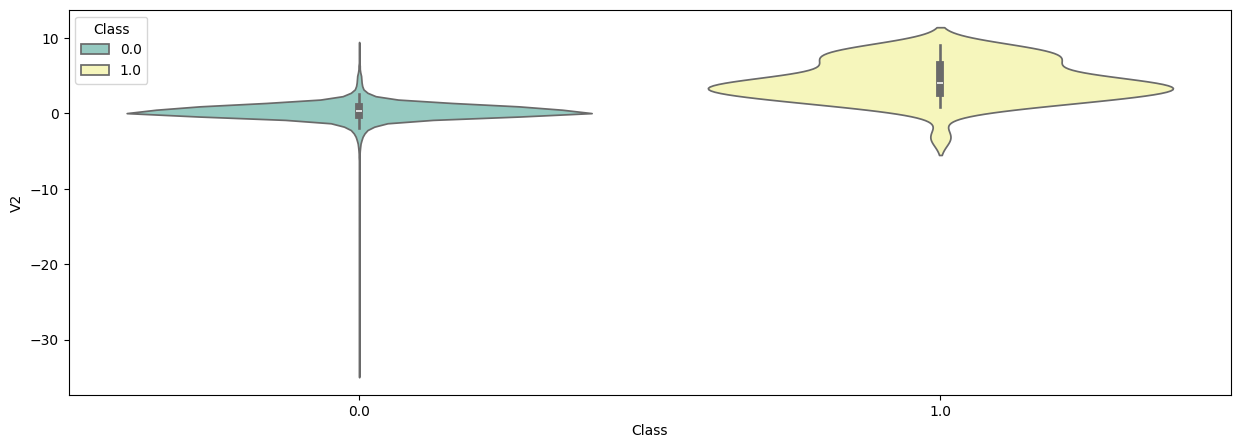

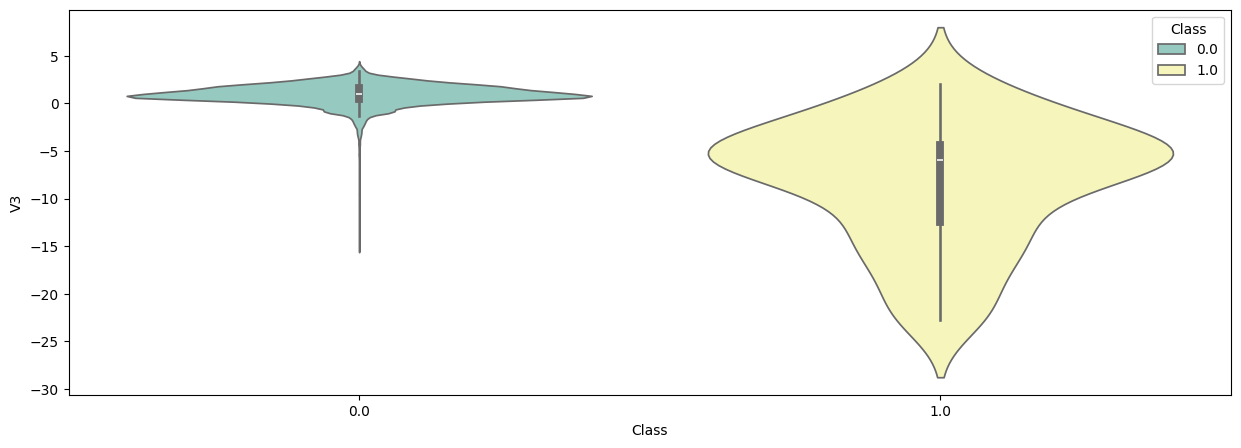

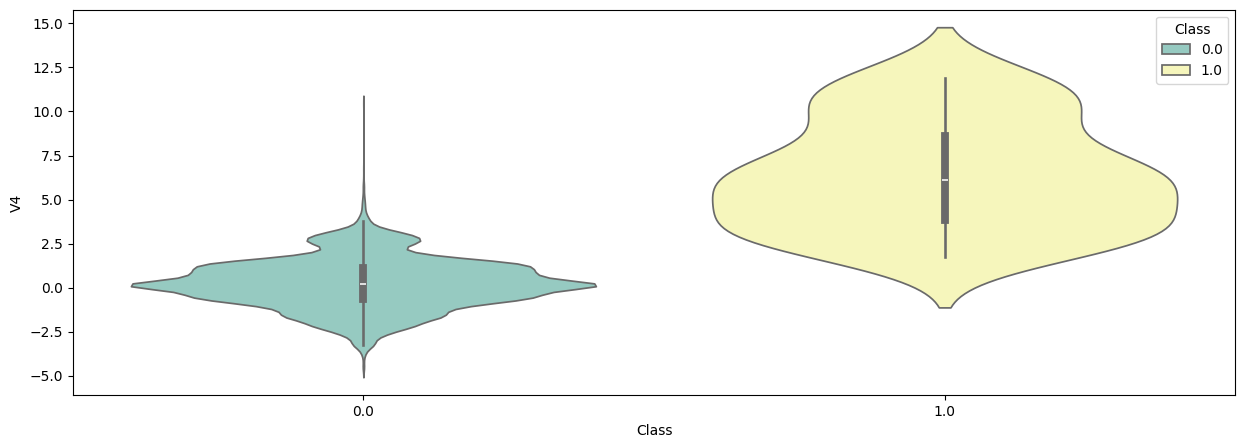

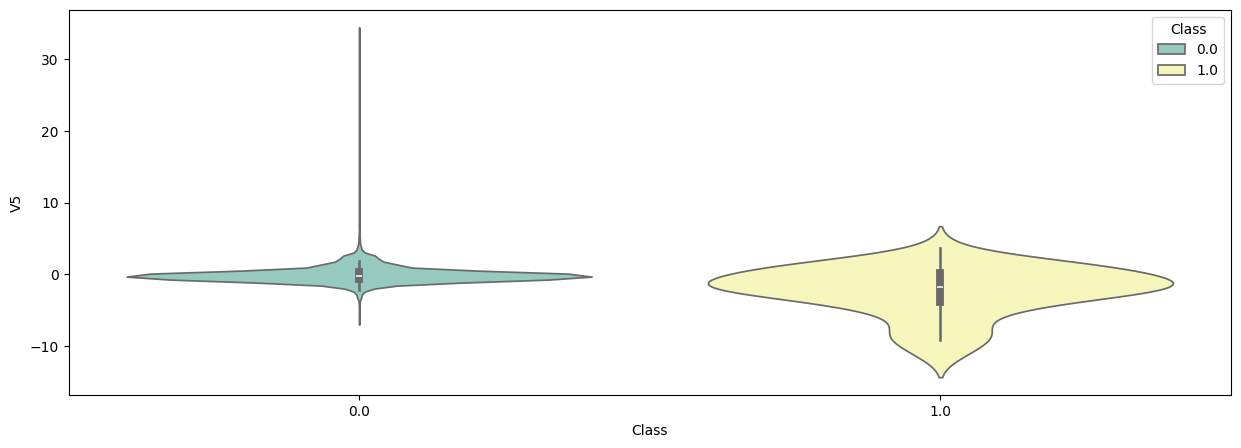

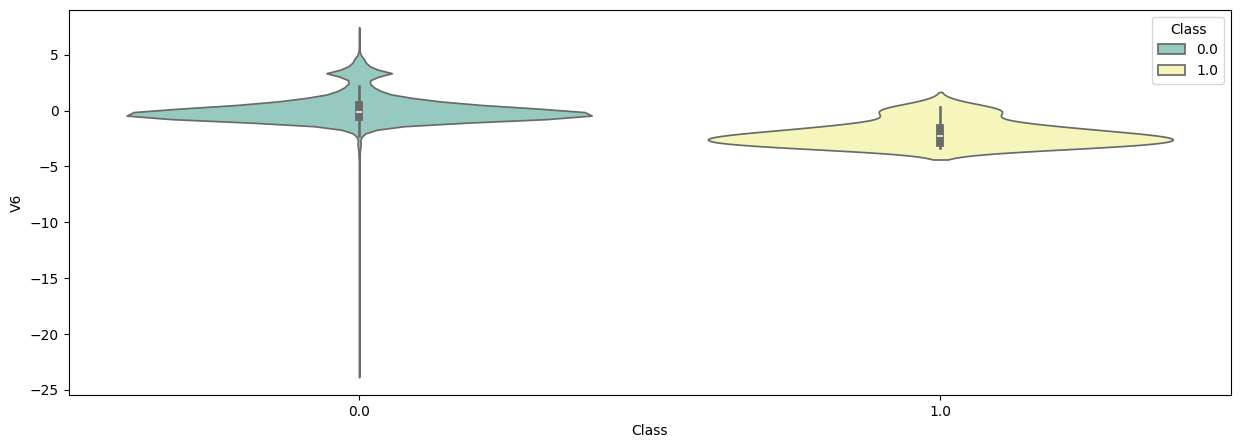

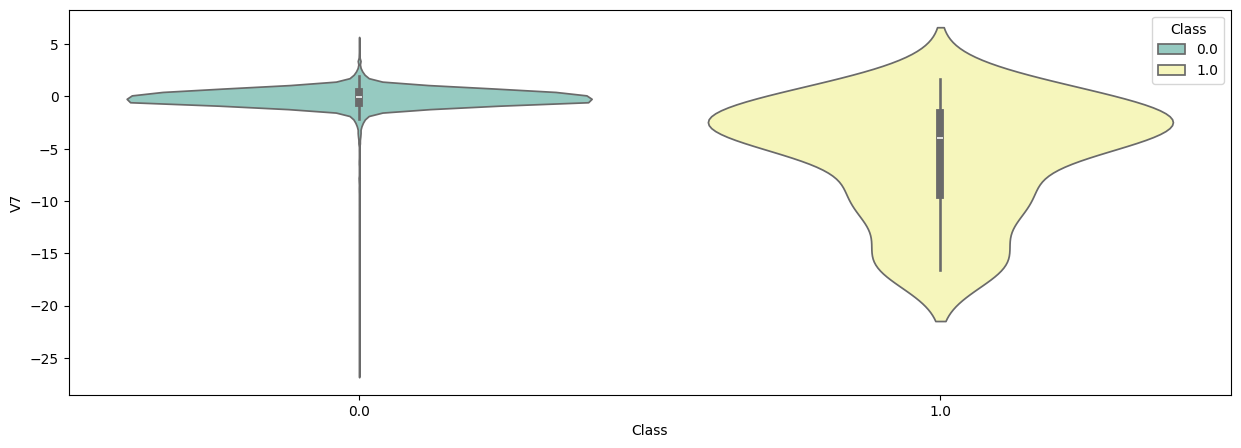

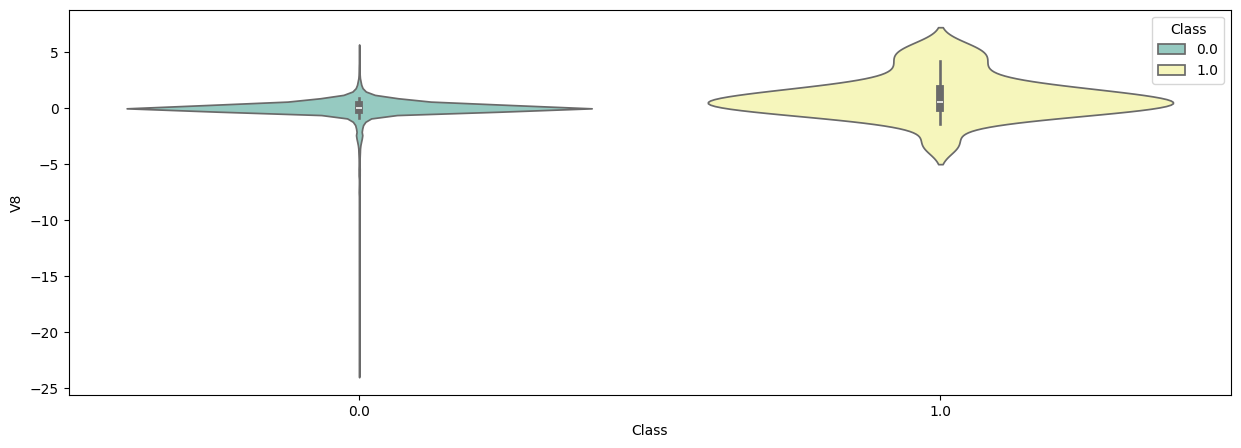

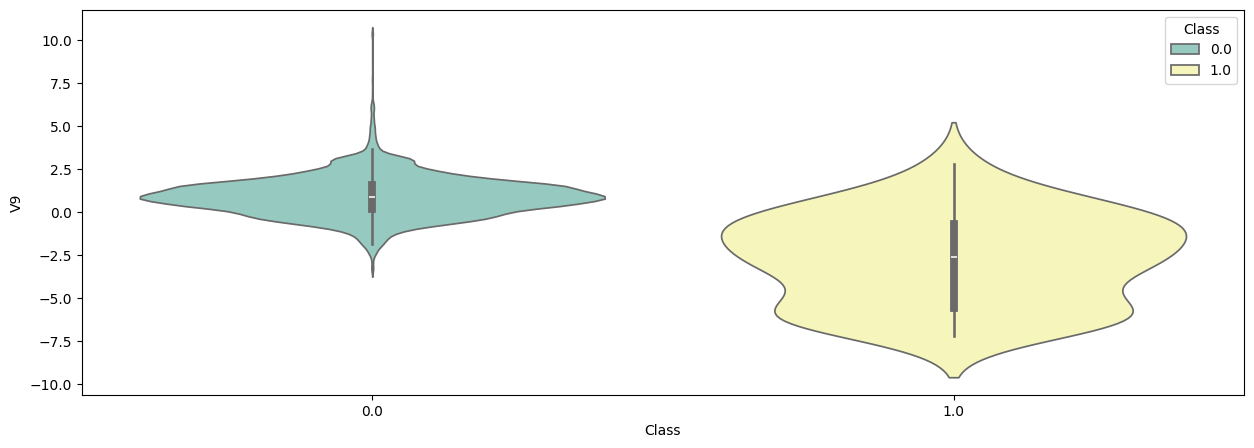

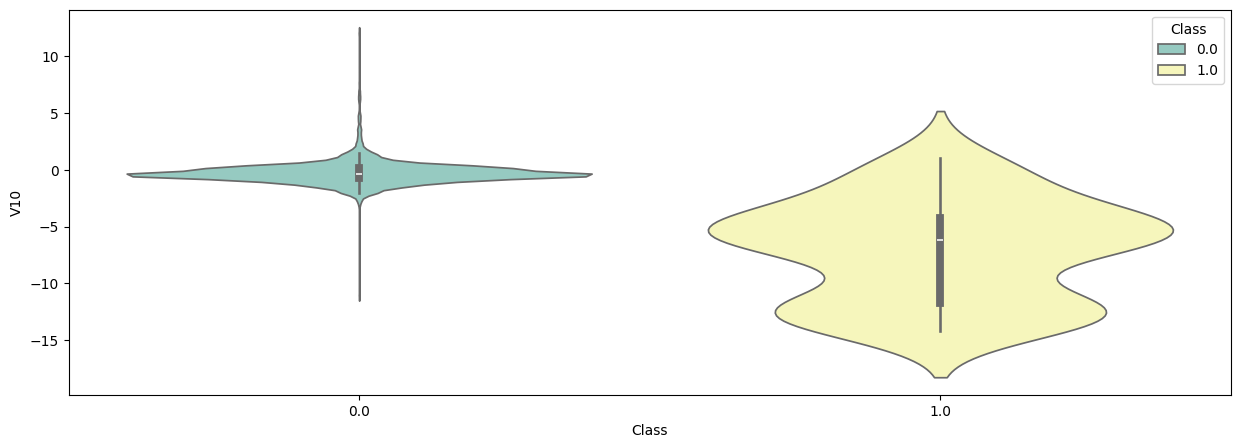

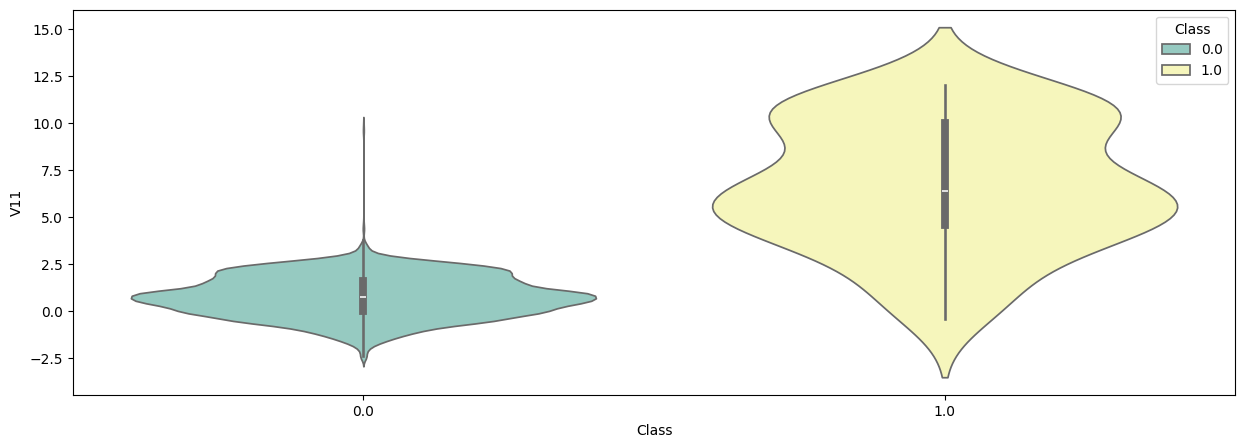

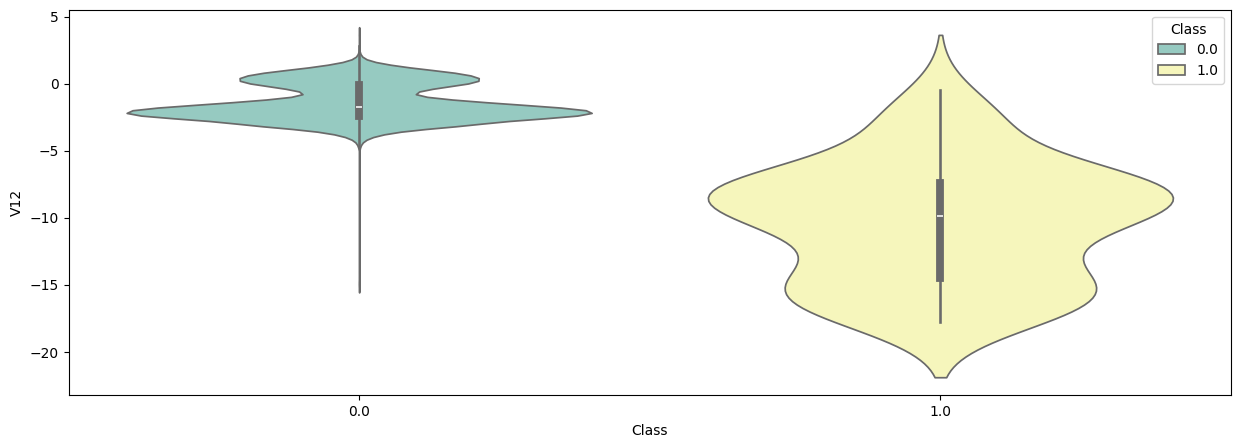

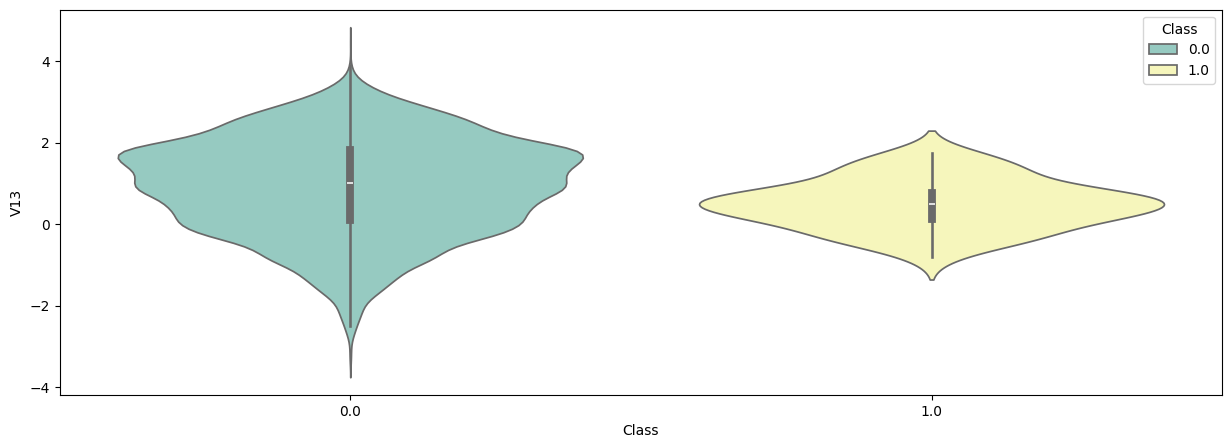

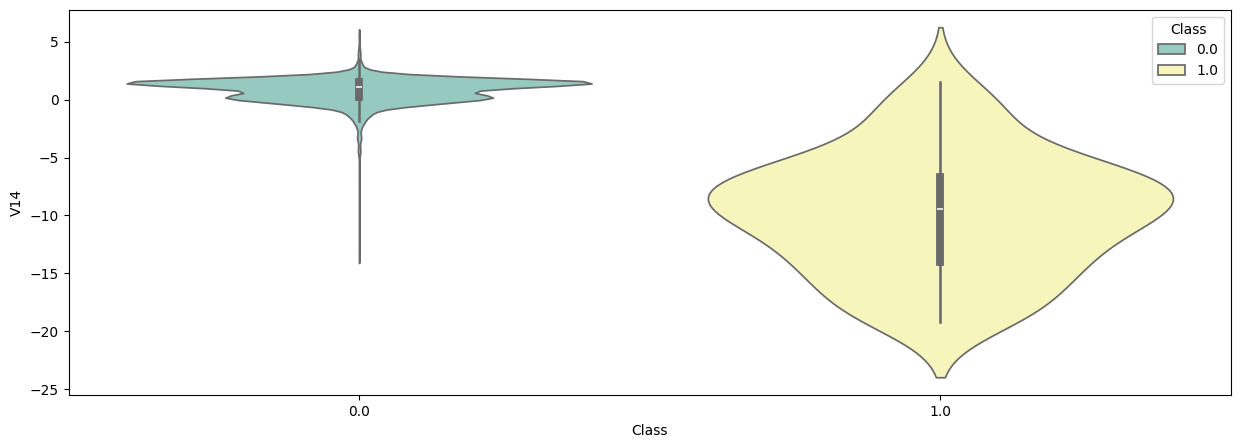

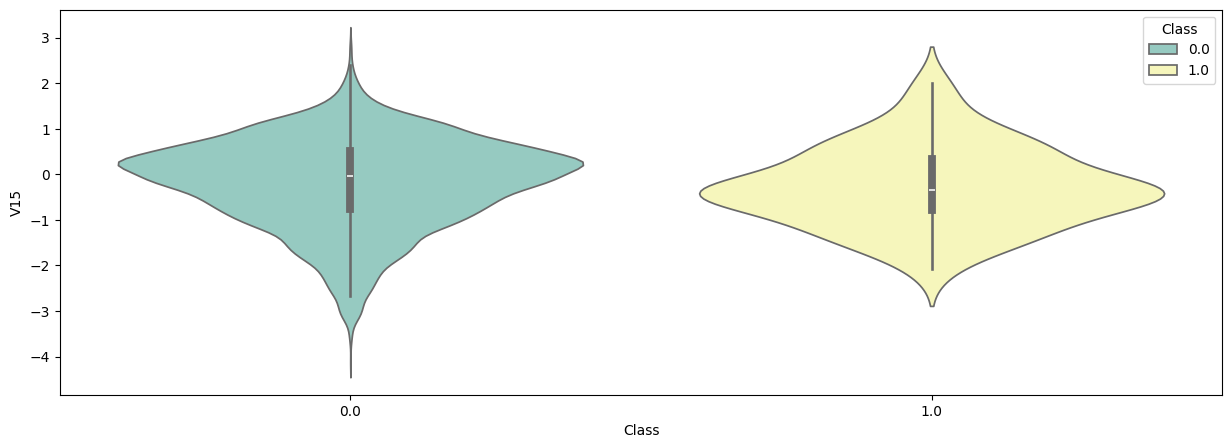

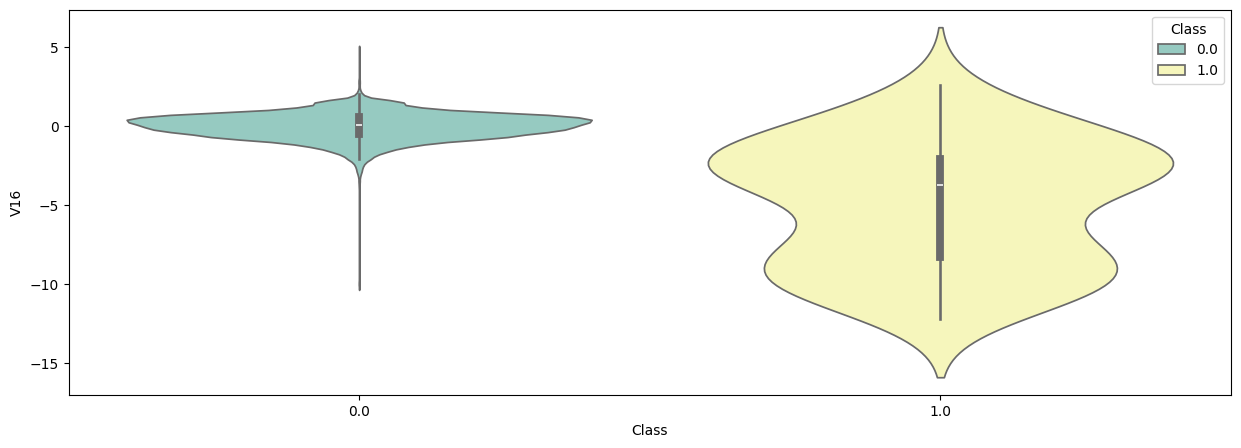

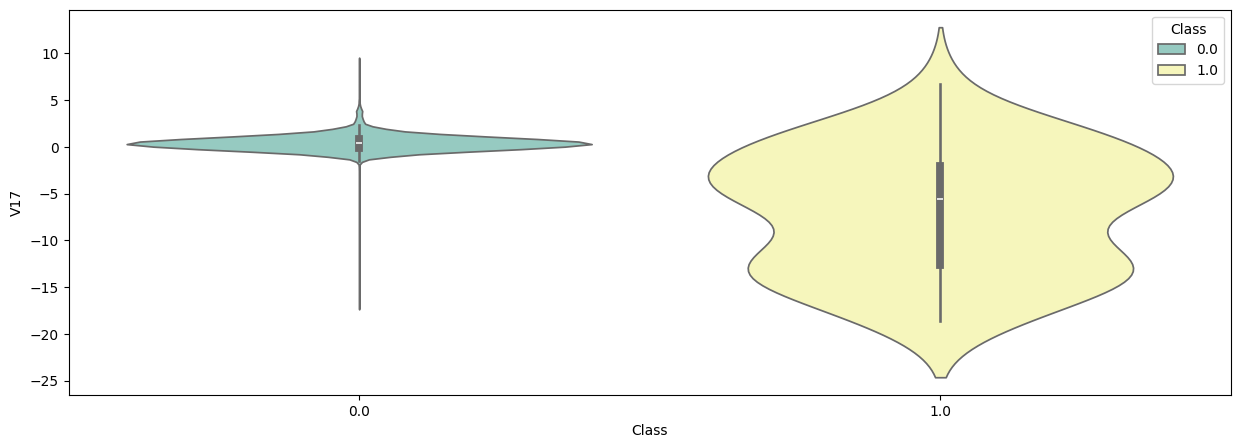

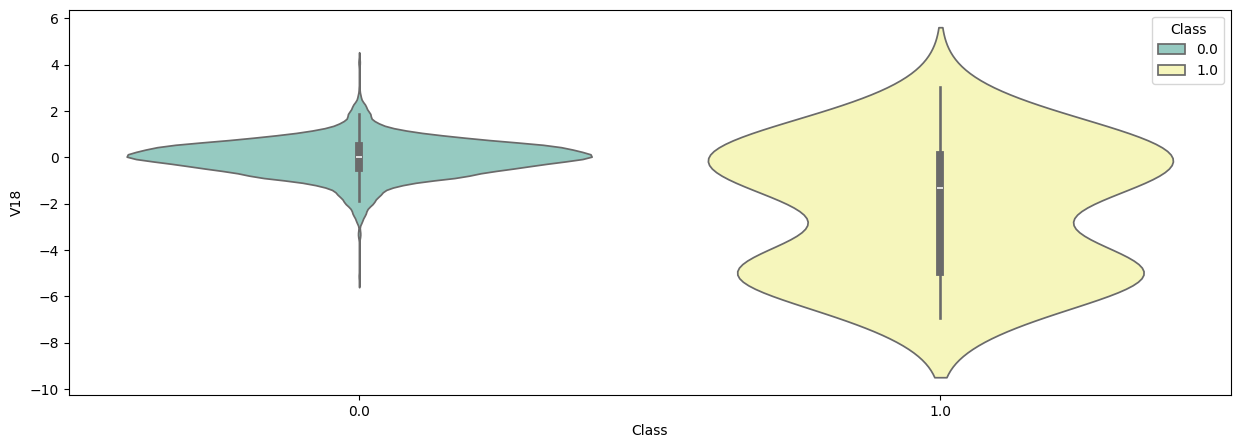

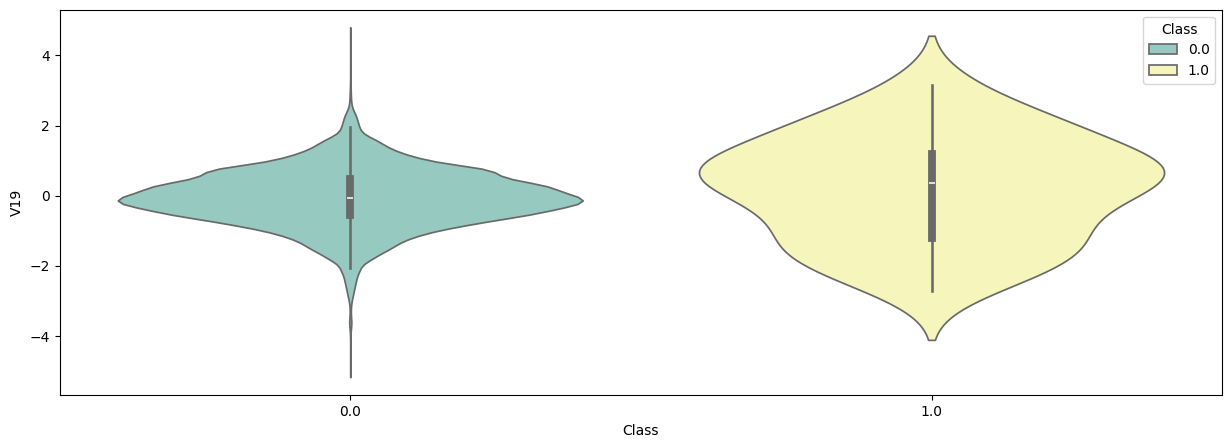

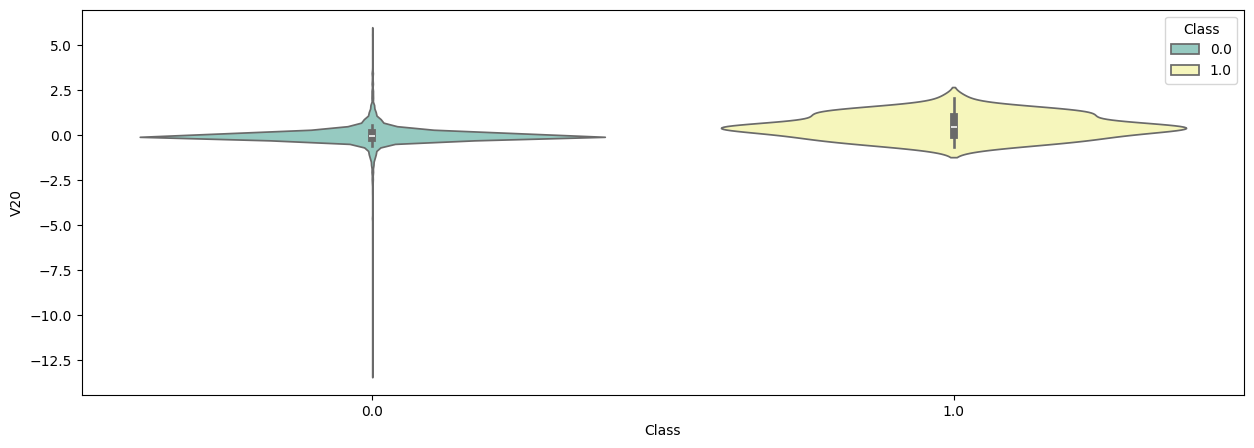

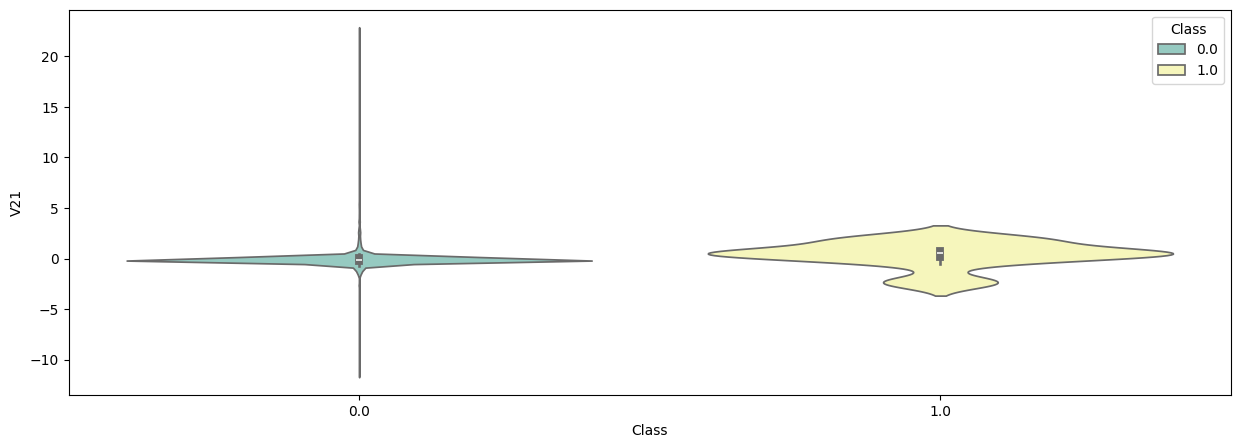

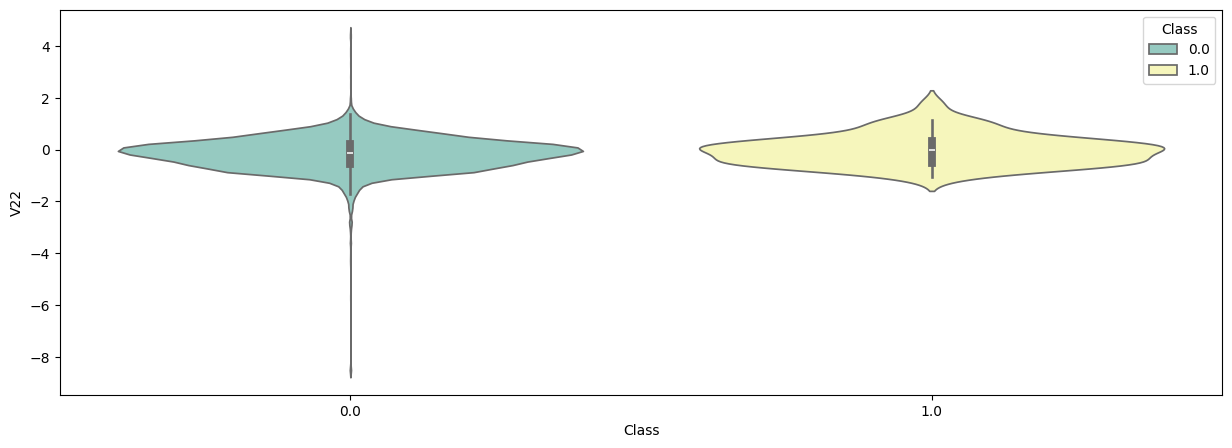

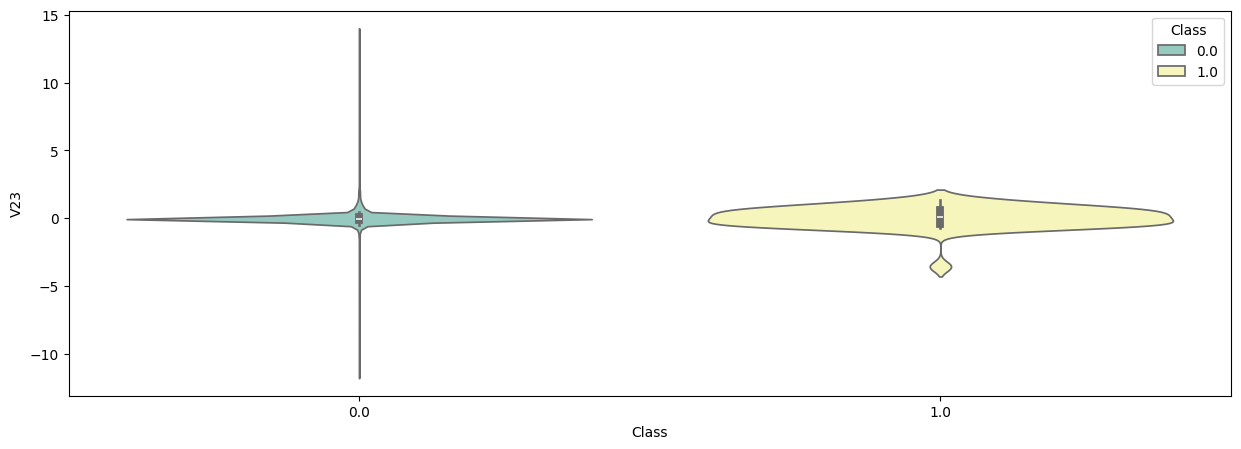

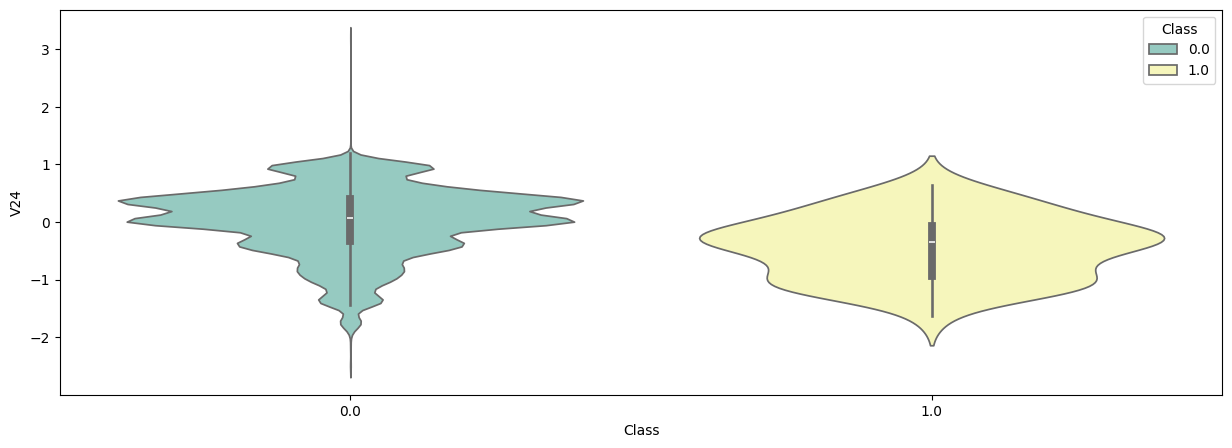

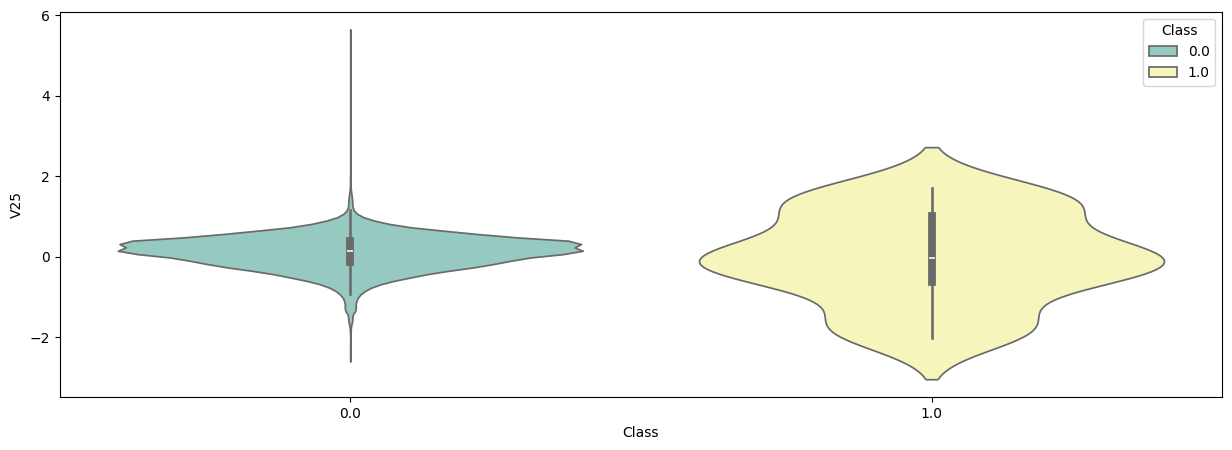

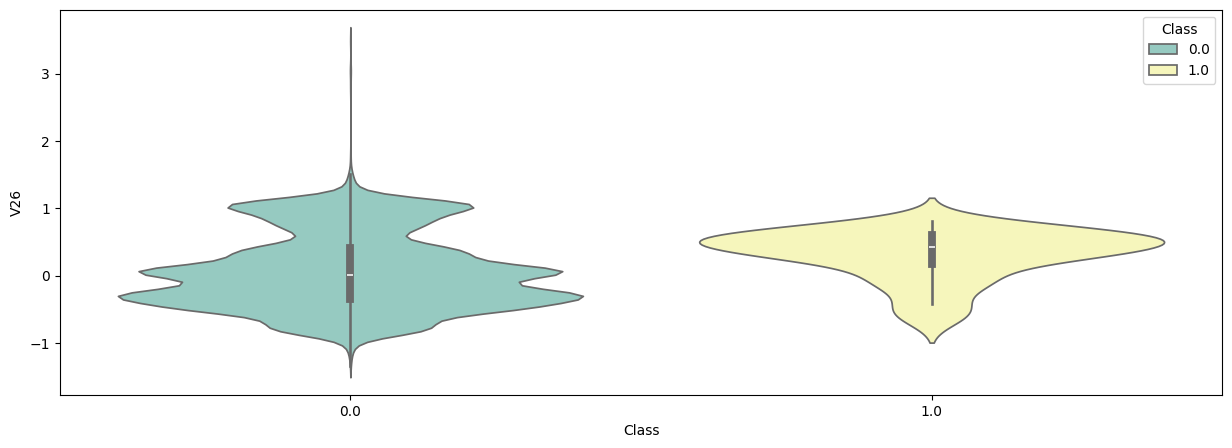

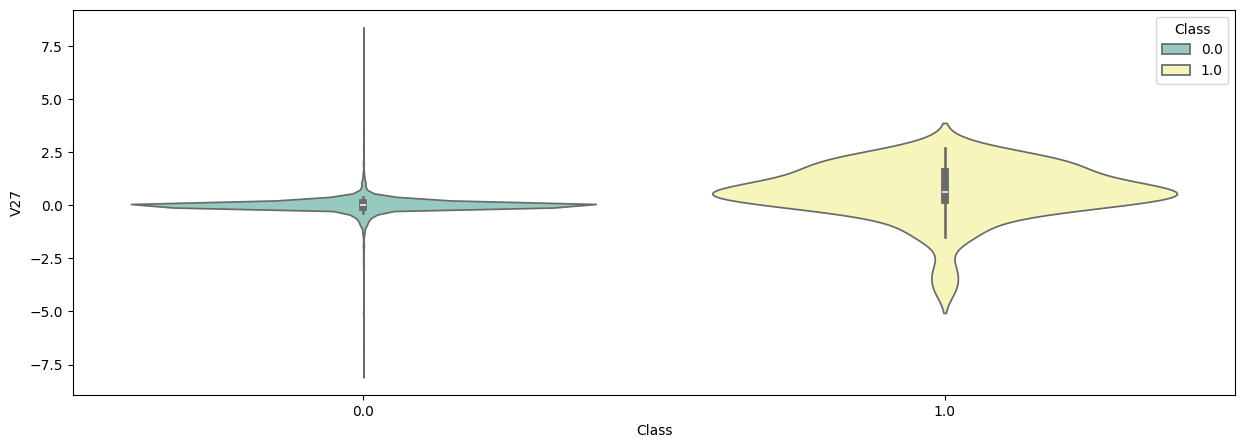

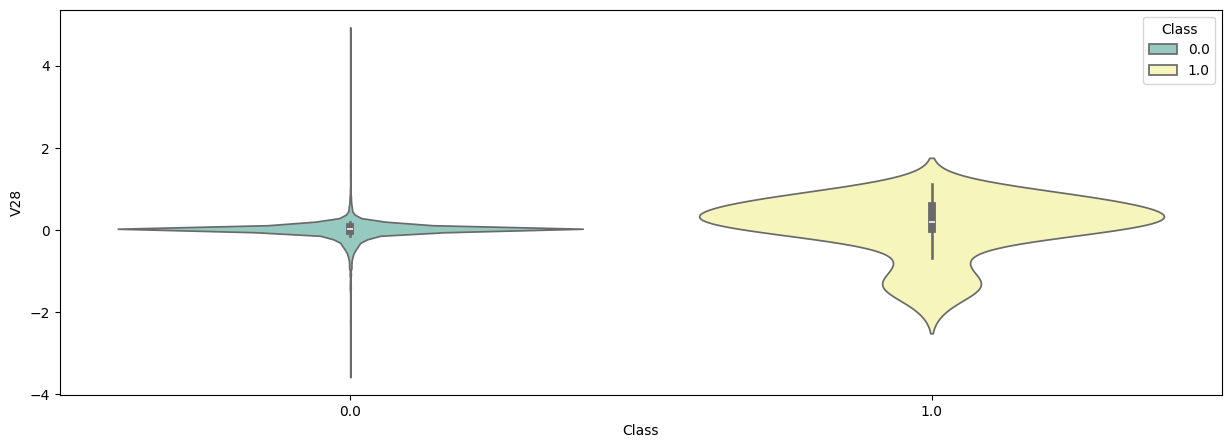

In [16]:
cols=df1.iloc[:,1:29]
for i in cols.columns:
    f, ax = plt.subplots(figsize=(15, 5))
    sns.violinplot(x="Class", y=i, data=df1, density_norm='area', palette="Set3", hue="Class")
    plt.show()


Let' drop all of the features that have very similar distributions between the two classes.

# TPOT

TPOT will automate the most tedious part of machine learning by intelligently exploring thousands of possible pipelines to find the best one for your data.

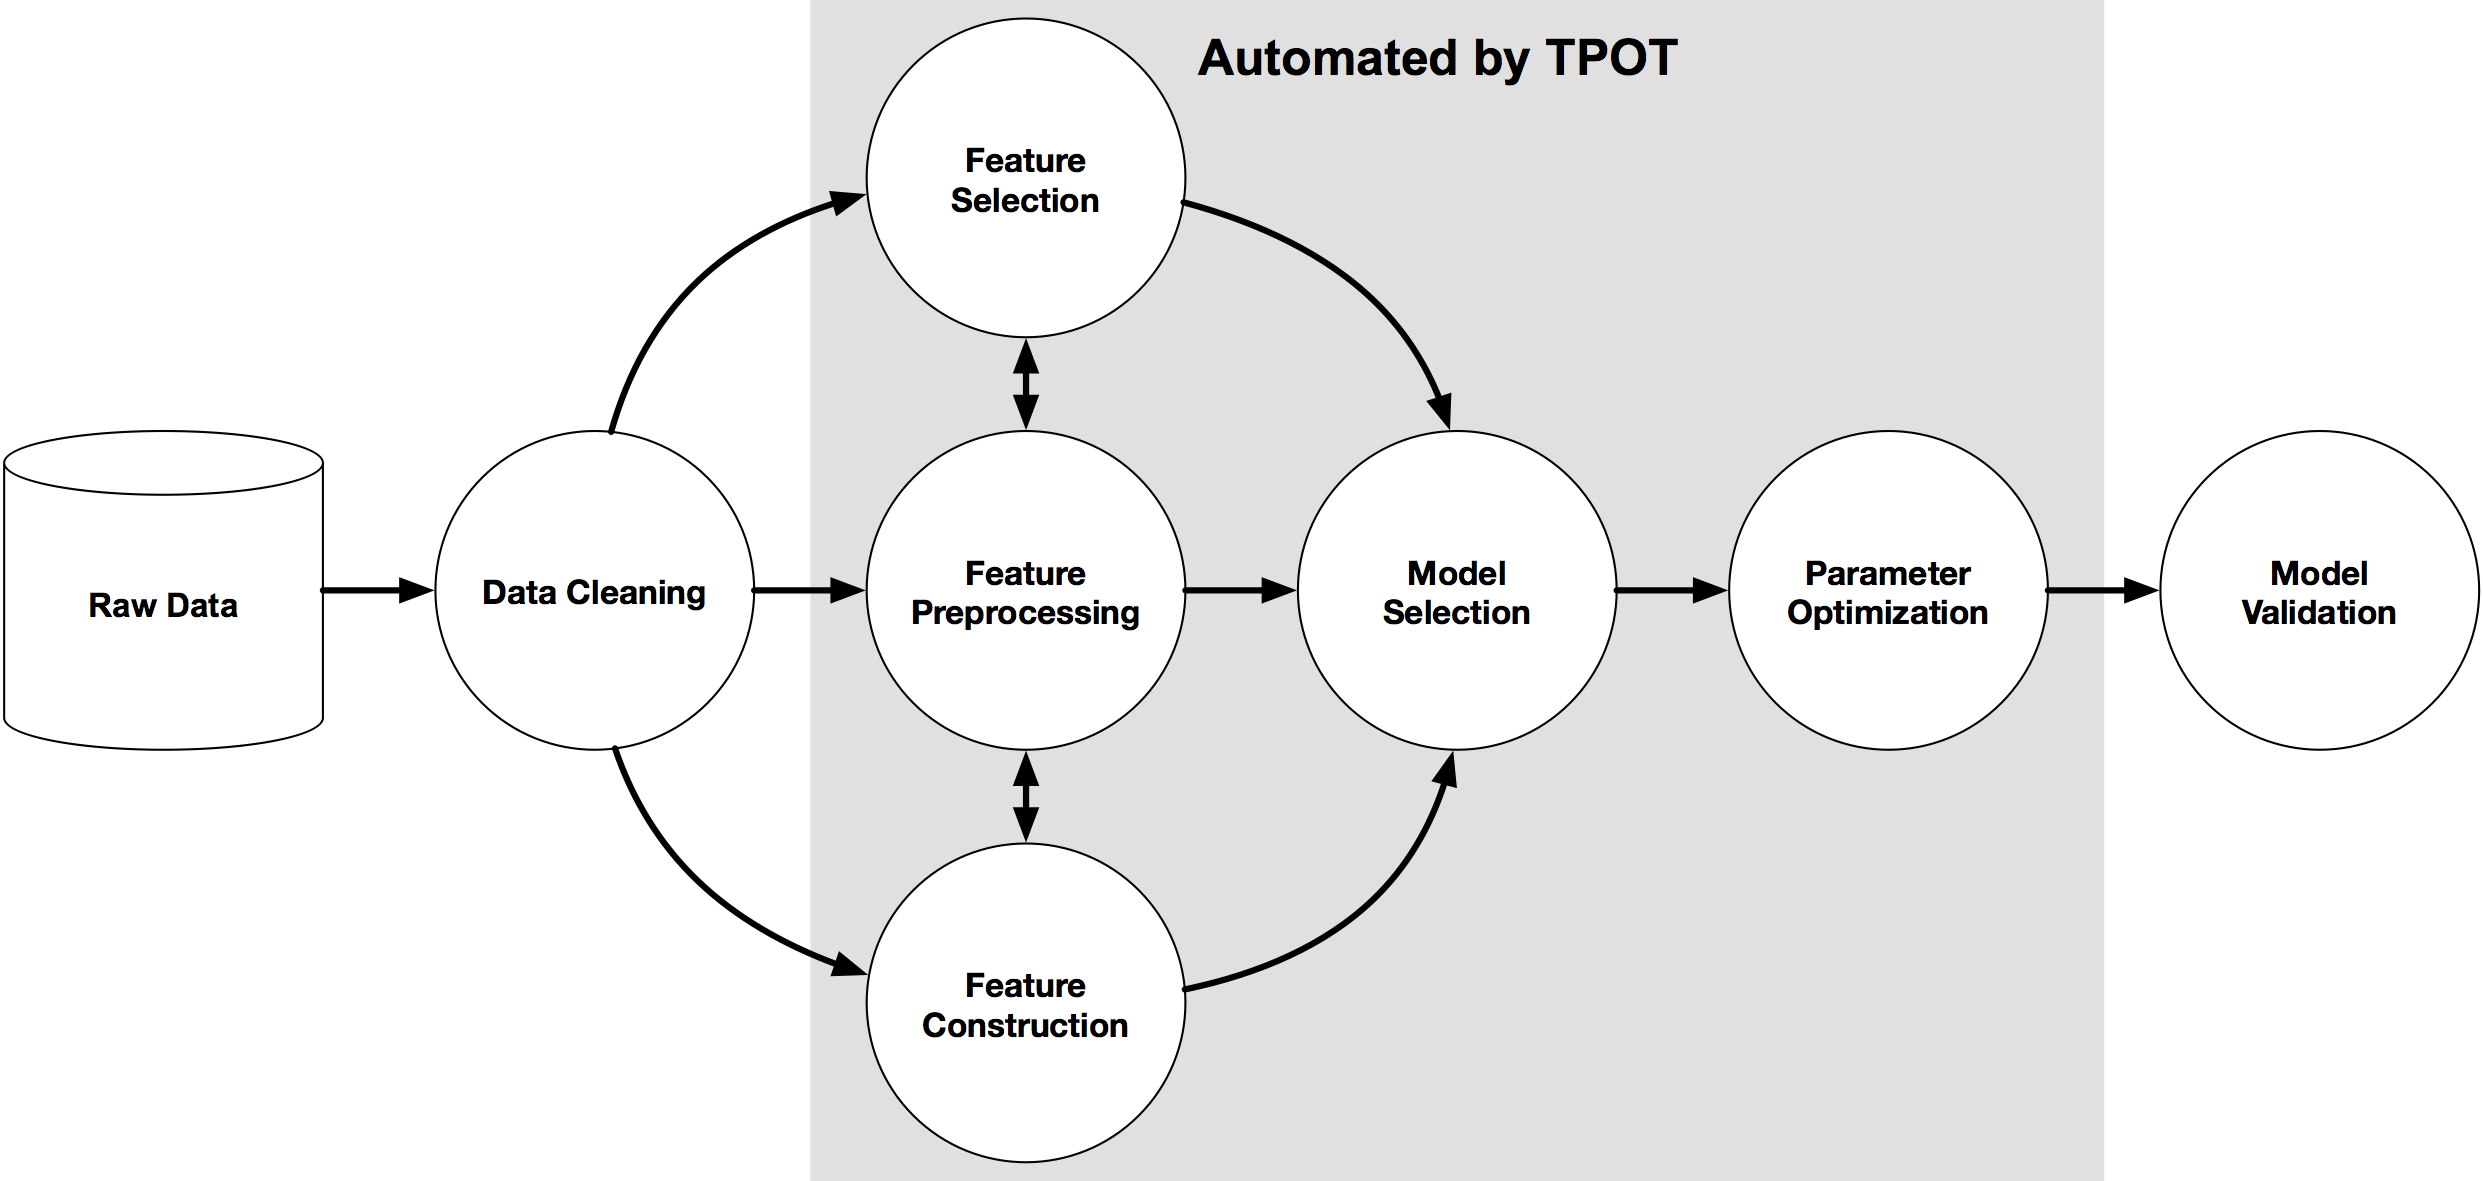

Once TPOT is finished searching (or you get tired of waiting), it provides you with the Python code for the best pipeline it found so you can tinker with the pipeline from there.

TPOT is built on top of scikit-learn, so all of the code it generates should look familiar.

In [65]:
! pip install --upgrade tpot

In [18]:
import tpot
print(tpot.__version__)

1.1.0


In [69]:
from tpot import TPOTClassifier

pipeline_optimizer = TPOTClassifier(
    generations=10,
    population_size=5,
    cv=5,
    n_jobs=2,
    random_state=42,
    max_eval_time_mins=5,
    periodic_checkpoint_folder="tpot_checkpoints",
    early_stop=4
)

In [67]:
target = df1['Class']
features = df1.drop(['Class'], axis=1)

In [70]:
pipeline_optimizer.fit(features, target)

/usr/local/lib/python3.12/dist-packages/tpot/tpot_estimator/estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:45901
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34373'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44547'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:42055 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:42055
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:52074
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:36897 na

TPOTClassifier(cv=5, early_stop=4, max_eval_time_mins=5, n_jobs=2,
               periodic_checkpoint_folder='tpot_checkpoints', random_state=42,
               search_space=<tpot.search_spaces.pipelines.sequential.SequentialPipeline object at 0x7dddd385fc50>)

In [71]:
data_cleaned = data.dropna()
all_features = data_cleaned.drop(['Class'], axis=1)
all_target = data_cleaned['Class']

pred = pipeline_optimizer.predict(all_features)

In [72]:
from sklearn.metrics import confusion_matrix,precision_recall_curve,auc,roc_auc_score,roc_curve,recall_score,classification_report

In [73]:
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        #print("Normalized confusion matrix")
    else:
        1#print('Confusion matrix, without normalization')

    #print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Recall metric in the testing dataset:  0.9038461538461539


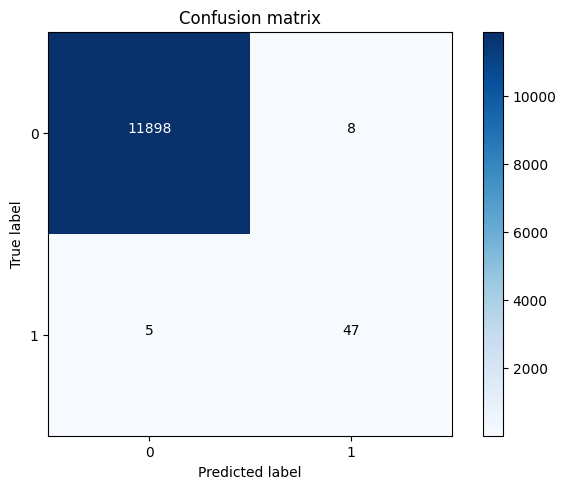

In [74]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(all_target, pred)
np.set_printoptions(precision=2)

print("Recall metric in the testing dataset: ", cnf_matrix[1,1]/(cnf_matrix[1,0]+cnf_matrix[1,1]))

# Plot non-normalized confusion matrix
class_names = [0,1]
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, title='Confusion matrix')
plt.show()

In [63]:
#pipeline_optimizer.export('tpot_best_model_pipeline.py')

In [61]:
# %%writefile app.py
# import streamlit as st
# import pandas as pd
# import numpy as np
# import pickle

# # Load the trained TPOT model
# @st.cache_resource
# def load_model():
#     with open('population.pkl', 'rb') as file:
#         model = pickle.load(file)
#     return model

# model = load_model()

# st.title('Credit Card Fraud Detection')
# st.write('Enter the transaction details to predict if it is fraudulent or not.')

# # Create input fields for each feature
# st.sidebar.header('Transaction Details')

# # Assuming you have 30 features (Time, V1-V28, Amount) as in your dataframe
# # For simplicity, let's create a few example input fields.
# # You would need to create input fields for all 30 features (excluding 'Class')

# def get_user_input():
#     Time = st.sidebar.number_input('Time (seconds since first transaction)', value=0.0)
#     V1 = st.sidebar.number_input('V1', value=0.0)
#     V2 = st.sidebar.number_input('V2', value=0.0)
#     V3 = st.sidebar.number_input('V3', value=0.0)
#     V4 = st.sidebar.number_input('V4', value=0.0)
#     V5 = st.sidebar.number_input('V5', value=0.0)
#     V6 = st.sidebar.number_input('V6', value=0.0)
#     V7 = st.sidebar.number_input('V7', value=0.0)
#     V8 = st.sidebar.number_input('V8', value=0.0)
#     V9 = st.sidebar.number_input('V9', value=0.0)
#     V10 = st.sidebar.number_input('V10', value=0.0)
#     V11 = st.sidebar.number_input('V11', value=0.0)
#     V12 = st.sidebar.number_input('V12', value=0.0)
#     V13 = st.sidebar.number_input('V13', value=0.0)
#     V14 = st.sidebar.number_input('V14', value=0.0)
#     V15 = st.sidebar.number_input('V15', value=0.0)
#     V16 = st.sidebar.number_input('V16', value=0.0)
#     V17 = st.sidebar.number_input('V17', value=0.0)
#     V18 = st.sidebar.number_input('V18', value=0.0)
#     V19 = st.sidebar.number_input('V19', value=0.0)
#     V20 = st.sidebar.number_input('V20', value=0.0)
#     V21 = st.sidebar.number_input('V21', value=0.0)
#     V22 = st.sidebar.number_input('V22', value=0.0)
#     V23 = st.sidebar.number_input('V23', value=0.0)
#     V24 = st.sidebar.number_input('V24', value=0.0)
#     V25 = st.sidebar.number_input('V25', value=0.0)
#     V26 = st.sidebar.number_input('V26', value=0.0)
#     V27 = st.sidebar.number_input('V27', value=0.0)
#     V28 = st.sidebar.number_input('V28', value=0.0)
#     Amount = st.sidebar.number_input('Amount', value=0.0)

#     # Create a dictionary of all features
#     user_data = {
#         'Time': Time,
#         'V1': V1,
#         'V2': V2,
#         'V3': V3,
#         'V4': V4,
#         'V5': V5,
#         'V6': V6,
#         'V7': V7,
#         'V8': V8,
#         'V9': V9,
#         'V10': V10,
#         'V11': V11,
#         'V12': V12,
#         'V13': V13,
#         'V14': V14,
#         'V15': V15,
#         'V16': V16,
#         'V17': V17,
#         'V18': V18,
#         'V19': V19,
#         'V20': V20,
#         'V21': V21,
#         'V22': V22,
#         'V23': V23,
#         'V24': V24,
#         'V25': V25,
#         'V26': V26,
#         'V27': V27,
#         'V28': V28,
#         'Amount': Amount
#     }
#     features = pd.DataFrame(user_data, index=[0])
#     return features

# input_df = get_user_input()

# st.subheader('User Input:')
# st.write(input_df)

# # Make prediction
# if st.button('Predict'):
#     prediction = model.predict(input_df)
#     prediction_proba = model.predict_proba(input_df)

#     st.subheader('Prediction:')
#     if prediction[0] == 0:
#         st.success('Transaction is likely NOT FRAUDULENT')
#     else:
#         st.error('Transaction is likely FRAUDULENT')

#     st.subheader('Prediction Probability:')
#     st.write(f'Not Fraudulent: {prediction_proba[0][0]:.4f}')
#     st.write(f'Fraudulent: {prediction_proba[0][1]:.4f}')


Overwriting app.py


The `tpot_best_model_pipeline.py` file has been exported. You can find this file in the current directory. You can then use the code within this file to load and retrain the model, and then save it in formats like `.keras` or `.h5` if the underlying scikit-learn compatible estimator supports it.

In [75]:
# import pickle

# Save the pipeline_optimizer object to a .pkl file
# with open('tpot_model.pkl', 'wb') as file:
    # pickle.dump(pipeline_optimizer.fitted_pipeline_, file)

# print("TPOT model saved to tpot_model.pkl")